In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import files
data=files.upload()

Saving dataset_heart.csv to dataset_heart.csv


In [ ]:
df=pd.read_csv('dataset_heart.csv')

In [ ]:
df.sample(5)

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
184,53,1,3,130,246,1,2,173,0,0.0,1,3,3,1
238,47,1,3,138,257,0,2,156,0,0.0,1,0,3,1
95,47,1,4,110,275,0,2,118,1,1.0,2,1,3,2
50,42,1,4,136,315,0,0,125,1,1.8,2,0,6,2
221,65,1,4,135,254,0,2,127,0,2.8,2,1,7,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major vessels      

In [ ]:
df.describe()

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
chest pain type,0
resting blood pressure,0
serum cholestoral,0
fasting blood sugar,0
resting electrocardiographic results,0
max heart rate,0
exercise induced angina,0
oldpeak,0


eda

In [ ]:
sns

<module 'seaborn' from '/usr/local/lib/python3.12/dist-packages/seaborn/__init__.py'>

In [ ]:
df['heart disease'].value_counts()

,count
heart disease,
1,150
2,120


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major vessels      

numerical columns
- resting blood sugar
- serum cholestrol
- max heart rate
- old peak


---


numerical but in ordinnal form
- chest pain type
- fasting blood sugar
- resting elecrocardiographic drugs
- exercise induce angina
- st segement
- major vessels
- thal (thalasemia patient severity)

In [ ]:
def check_outliers(dataframe, column_name):
    # 1. Calculate the 25th and 75th percentiles (Q1 and Q3)
    q1 = dataframe[column_name].quantile(0.25)
    q3 = dataframe[column_name].quantile(0.75)

    # 2. Compute the Interquartile Range (IQR)
    iqr = q3 - q1

    # 3. Define the fences (boundaries)
    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)

    # 4. Count how many data points fall outside the fences
    min_outliers = dataframe[dataframe[column_name] < lower_fence].shape[0]
    max_outliers = dataframe[dataframe[column_name] > upper_fence].shape[0]

    # 5. Display the diagnostic report
    print(f"📊 --- Outlier Report for '{column_name}' ---")
    print(f"Lower Fence (Min Limit): {lower_fence:.2f} | Found: {min_outliers} minimum outliers")
    print(f"Upper Fence (Max Limit): {upper_fence:.2f} | Found: {max_outliers} maximum outliers")
    print(f"Total Outliers in Column: {min_outliers + max_outliers}\n")
    # Check your Total Spend column
check_outliers(df,'resting blood pressure')
check_outliers(df,'serum cholestoral')
check_outliers(df,'oldpeak')
check_outliers(df,'max heart rate')

📊 --- Outlier Report for 'resting blood pressure' ---
Lower Fence (Min Limit): 90.00 | Found: 0 minimum outliers
Upper Fence (Max Limit): 170.00 | Found: 0 maximum outliers
Total Outliers in Column: 0

📊 --- Outlier Report for 'serum cholestoral' ---
Lower Fence (Min Limit): 112.50 | Found: 0 minimum outliers
Upper Fence (Max Limit): 380.50 | Found: 0 maximum outliers
Total Outliers in Column: 0

📊 --- Outlier Report for 'oldpeak' ---
Lower Fence (Min Limit): -2.40 | Found: 0 minimum outliers
Upper Fence (Max Limit): 4.00 | Found: 0 maximum outliers
Total Outliers in Column: 0

📊 --- Outlier Report for 'max heart rate' ---
Lower Fence (Min Limit): 83.50 | Found: 0 minimum outliers
Upper Fence (Max Limit): 215.50 | Found: 0 maximum outliers
Total Outliers in Column: 0



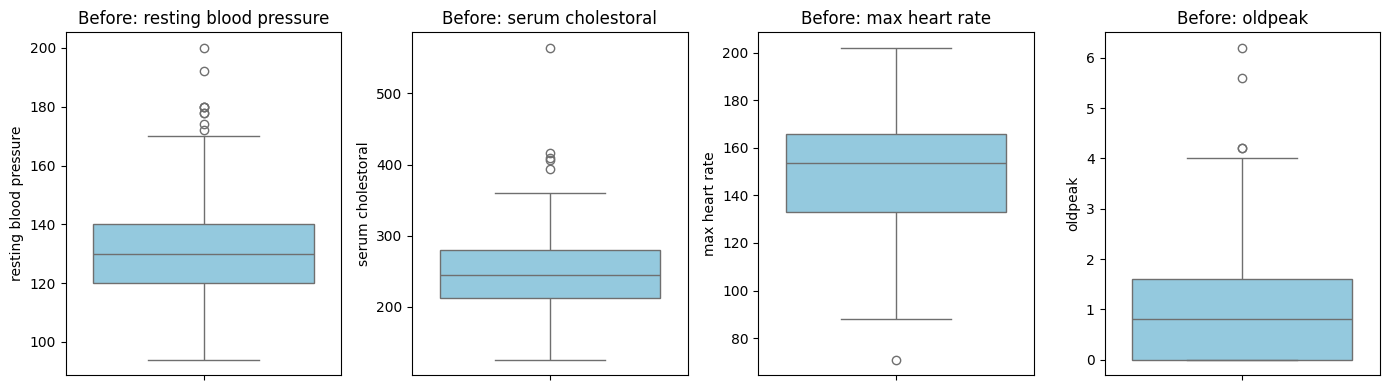

In [ ]:
# 2. Visualize Boxplots Before Capping
cont_cols = ['resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']
plt.figure(figsize=(14, 4))
for i, col in enumerate(cont_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Before: {col}')
plt.tight_layout()
plt.show()

In [ ]:
#Apply Winsorization (Capping)
df = df.copy()
for col in cont_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

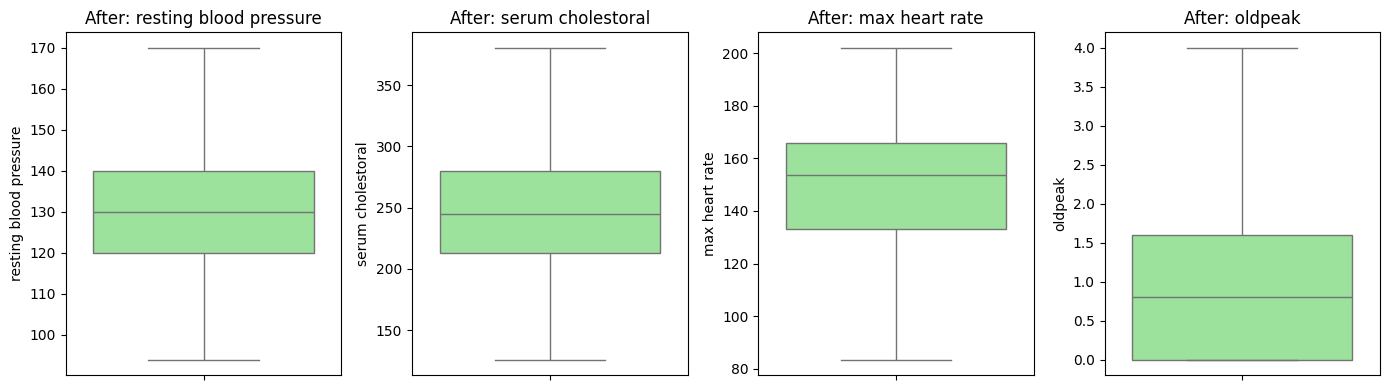

In [ ]:
#Visualize Boxplots After Capping
plt.figure(figsize=(14, 4))
for i, col in enumerate(cont_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'After: {col}')
plt.tight_layout()
plt.show()

checking outlier in categorical col

In [ ]:
catecol=['chest pain type','fasting blood sugar','resting electrocardiographic results','exercise induced angina','ST segment','major vessels','thal',]
df[catecol].nunique()

,0
chest pain type,4
fasting blood sugar,2
resting electrocardiographic results,3
exercise induced angina,2
ST segment,3
major vessels,4
thal,3


In [ ]:
# Loop through each categorical column individually
for col in catecol:
    print(f"--- Value Counts for '{col}' ---")
    print(df[col].value_counts())
    print("\n" + "="*40 + "\n")

--- Value Counts for 'chest pain type' ---
chest pain type
4    129
3     79
2     42
1     20
Name: count, dtype: int64


--- Value Counts for 'fasting blood sugar' ---
fasting blood sugar
0    230
1     40
Name: count, dtype: int64


--- Value Counts for 'resting electrocardiographic results' ---
resting electrocardiographic results
2    137
0    131
1      2
Name: count, dtype: int64


--- Value Counts for 'exercise induced angina' ---
exercise induced angina
0    181
1     89
Name: count, dtype: int64


--- Value Counts for 'ST segment' ---
ST segment
1    130
2    122
3     18
Name: count, dtype: int64


--- Value Counts for 'major vessels' ---
major vessels
0    160
1     58
2     33
3     19
Name: count, dtype: int64


--- Value Counts for 'thal' ---
thal
3    152
7    104
6     14
Name: count, dtype: int64




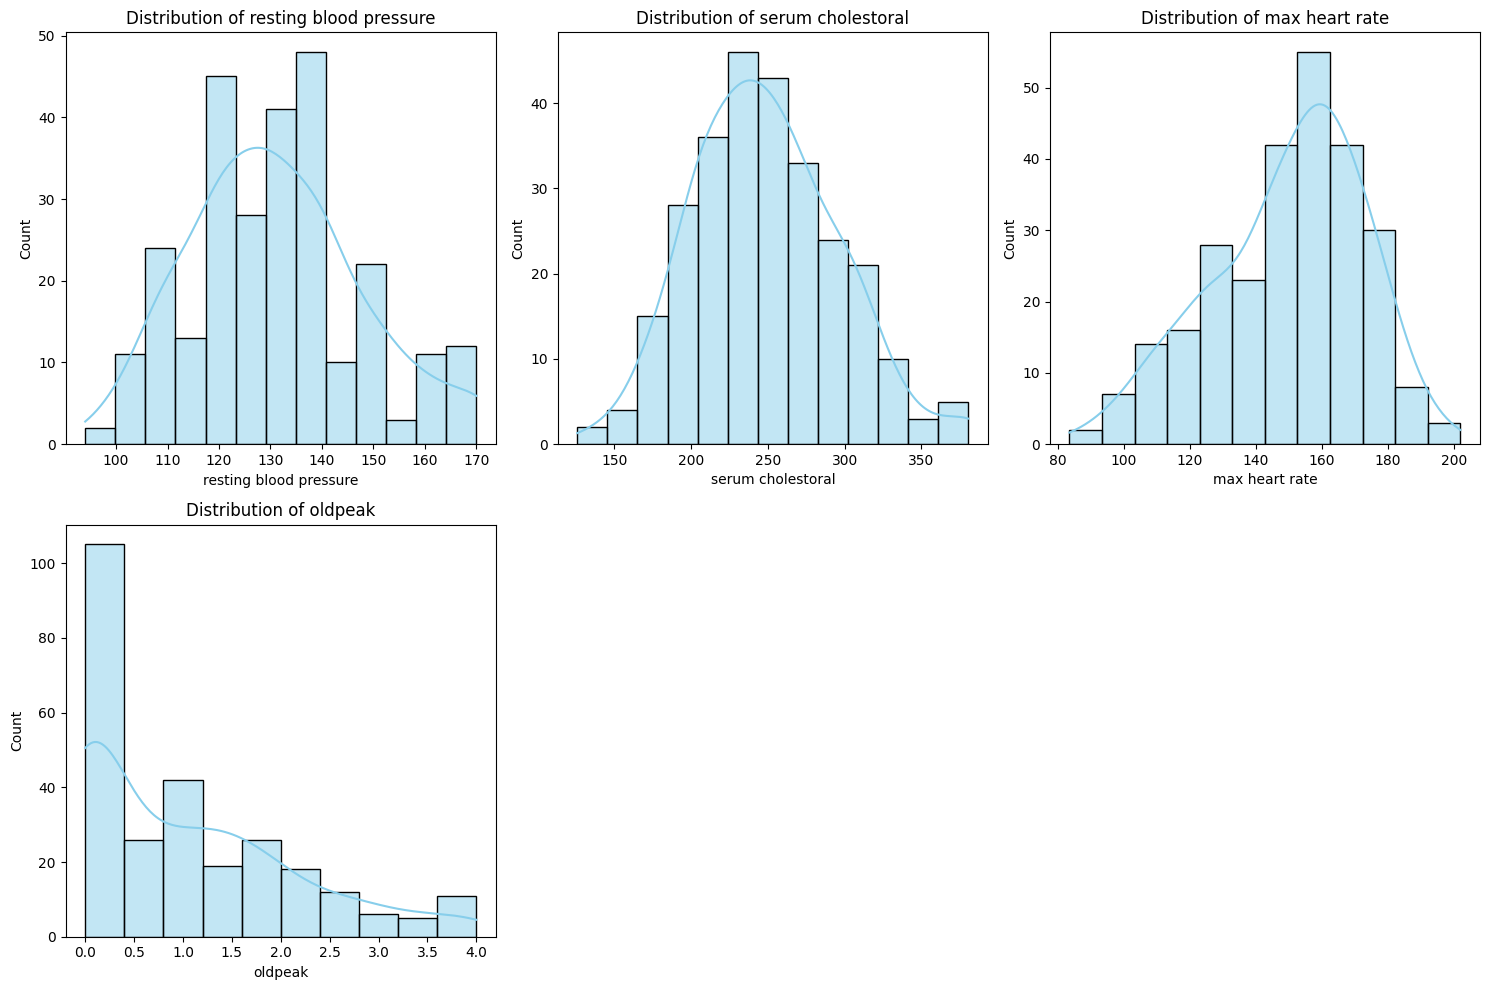

In [ ]:
# Plot KDE + Histogram for numerical columns
cont_cols = ['resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cont_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()
plt.close()


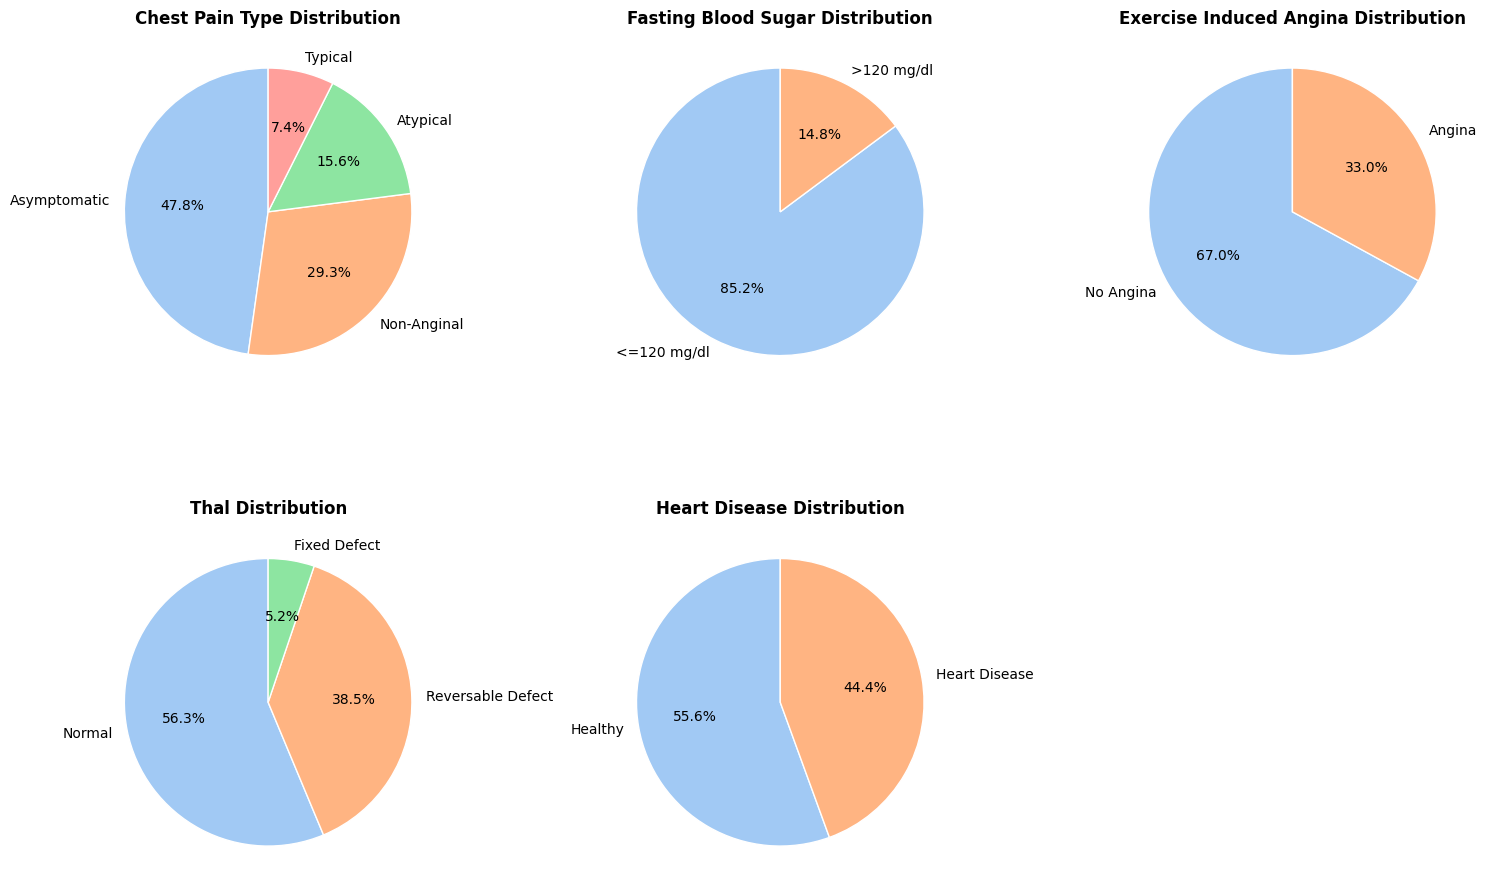

In [ ]:
# Create a mapped copy for visualization only
df_mapped = df.copy()
df_mapped['chest pain type'] = df_mapped['chest pain type'].map({1: 'Typical', 2: 'Atypical', 3: 'Non-Anginal', 4: 'Asymptomatic'})
df_mapped['fasting blood sugar'] = df_mapped['fasting blood sugar'].map({0: '<=120 mg/dl', 1: '>120 mg/dl'})
df_mapped['exercise induced angina'] = df_mapped['exercise induced angina'].map({0: 'No Angina', 1: 'Angina'})
df_mapped['thal'] = df_mapped['thal'].map({3: 'Normal', 6: 'Fixed Defect', 7: 'Reversable Defect'})
df_mapped['heart disease'] = df_mapped['heart disease'].map({1: 'Healthy', 2: 'Heart Disease'})

# Select mapped categorical columns to plot
mapped_cats = ['chest pain type', 'fasting blood sugar', 'exercise induced angina', 'thal', 'heart disease']

plt.figure(figsize=(15, 10))
for i, col in enumerate(mapped_cats, 1):
    plt.subplot(2, 3, i)
    df_mapped[col].value_counts().plot.pie(
        autopct='%1.1f%%',
        colors=sns.color_palette('pastel'),
        startangle=90,
        wedgeprops={'edgecolor': 'white'}
    )
    plt.title(f'{col.title()} Distribution', fontsize=12, fontweight='bold')
    plt.ylabel('')

plt.tight_layout()
plt.show()

`H1` (Chest Pain)	Patients with asymptomatic chest pain (Type 4) are more likely to have heart disease than patients with typical/atypical pain.	CONFIRMED	70.5% of asymptomatic patients have heart disease, compared to only 16.7%–25.0% for other pain types.


---
H2 (Thalassemia)	Patients with reversible thalassemia defects (thal = 7) have a significantly higher rate of heart disease.	CONFIRMED	76.0% of patients with reversible defects have heart disease, compared to 21.7% with normal results.

---
H3 (Blood Sugar)High fasting blood sugar ($> 120 \text{ mg/dl}$) is strongly associated with the presence of heart disease.REJECTED42.5% of high blood sugar patients have heart disease vs. 44.8% of normal blood sugar patients (virtually no difference in this dataset).

---
H4 (Exercise Pain)	A large portion of heart disease patients do not experience angina (chest pain) during exercise ("silent" ischemia).	CONFIRMED	46.7% of heart disease patients experience NO exercise-induced angina, while 53.3% do.

---
H5 (Age vs. Max HR)Older patients achieve a lower maximum heart rate (thalach) during exertion.CONFIRMED Strong negative linear correlation ($r \approx -0.39$) between age and maximum heart rate.

---
`h6` sex vs heart disease :this represent mostly male have heart disease then females


---
`h7:` number of vessels and heart disease :this represent less number of vessel a patient have more is the chances of patient to be healthier

---
`h8` age sex and disease 🇰
- from this i analyze that male with 50 are healthier and with ~56 are not healthier and for female ~60 age is not healthier and for healthier almost 52 is healthier
  - Males develop heart disease earlier in life (mean age ~56).
  - Females develop heart disease significantly later in life (mean age ~60). Medical research supports this lag, as estrogen provides protective cardiovascular effects prior to menopause.









In [ ]:
# Plot KDE + Histogram for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(cont_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.savefig('numerical_distributions.png')
plt.close()



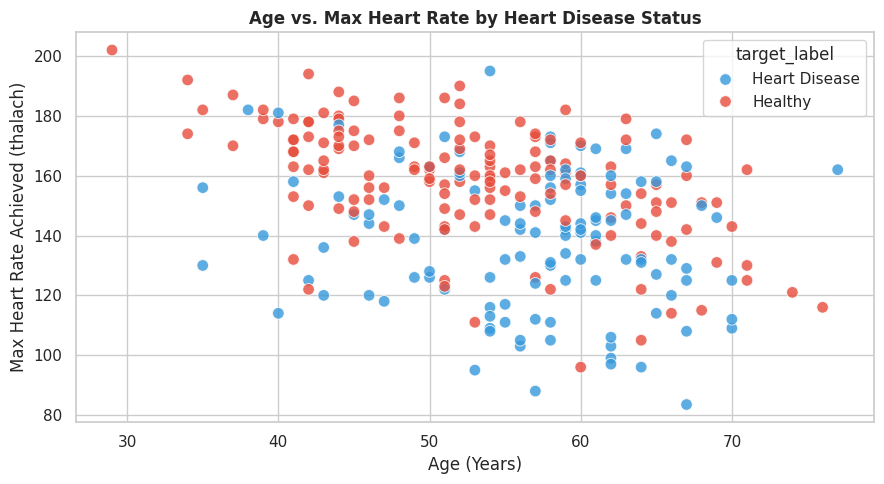

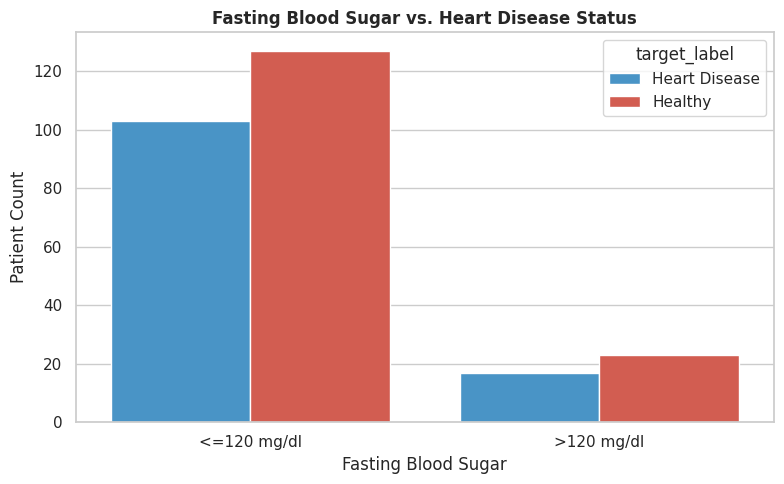

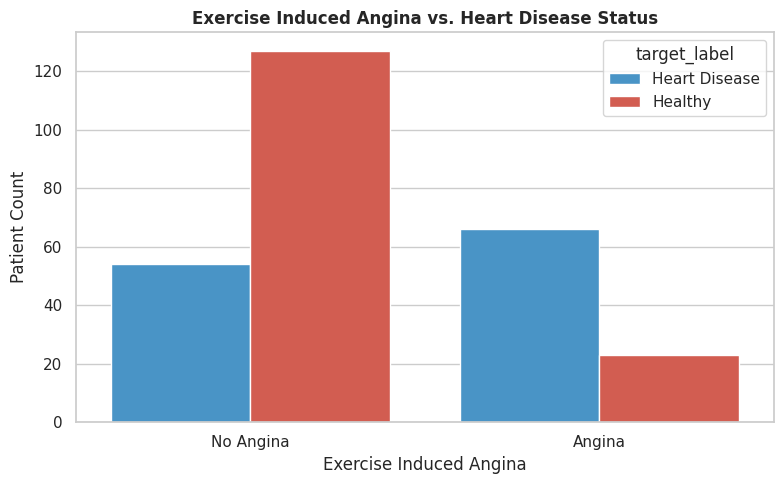

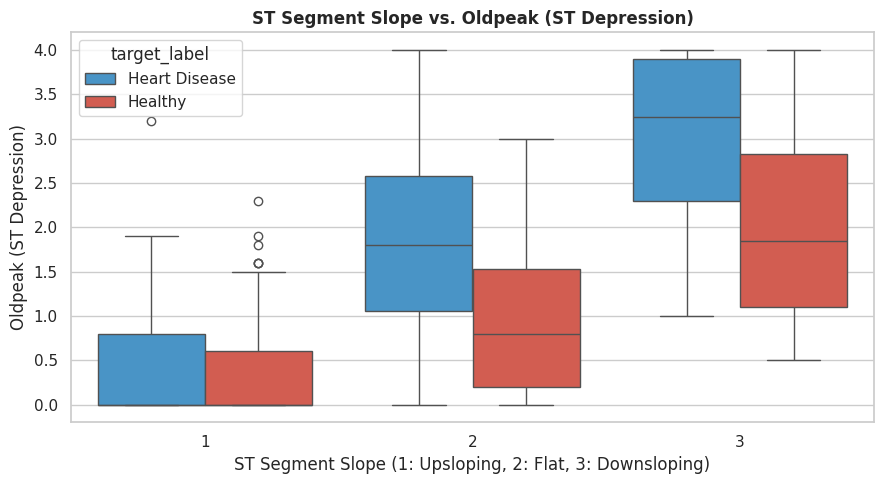

In [ ]:
# Ensure column names are clean
df.columns = df.columns.str.strip()

# Map labels for clear visual interpretation
df_mapped = df.copy()
df_mapped['target_label'] = df_mapped['heart disease'].map({1: 'Healthy', 2: 'Heart Disease'})
df_mapped['fbs_label'] = df_mapped['fasting blood sugar'].map({0: '<=120 mg/dl', 1: '>120 mg/dl'})
df_mapped['exang_label'] = df_mapped['exercise induced angina'].map({0: 'No Angina', 1: 'Angina'})

# Set plotting style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Plot 1: Age vs Max Heart Rate (Numerical Feature Interaction)
# ---------------------------------------------------------
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_mapped,
    x='age',
    y='max heart rate',
    hue='target_label',
    palette=['#3498db', '#e74c3c'],
    alpha=0.8,
    s=70
)
plt.title('Age vs. Max Heart Rate by Heart Disease Status', fontsize=12, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Max Heart Rate Achieved (thalach)')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Plot 2: Fasting Blood Sugar vs Target (Testing H3)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_mapped,
    x='fbs_label',
    hue='target_label',
    palette=['#3498db', '#e74c3c']
)
plt.title('Fasting Blood Sugar vs. Heart Disease Status', fontsize=12, fontweight='bold')
plt.xlabel('Fasting Blood Sugar')
plt.ylabel('Patient Count')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Plot 3: Exercise Angina vs Target (Testing H4)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_mapped,
    x='exang_label',
    hue='target_label',
    palette=['#3498db', '#e74c3c']
)
plt.title('Exercise Induced Angina vs. Heart Disease Status', fontsize=12, fontweight='bold')
plt.xlabel('Exercise Induced Angina')
plt.ylabel('Patient Count')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Plot 4: ST Depression vs Slope (Numerical/Ordinal Feature Interaction)
# ---------------------------------------------------------
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_mapped,
    x='ST segment',
    y='oldpeak',
    hue='target_label',
    palette=['#3498db', '#e74c3c']
)
plt.title('ST Segment Slope vs. Oldpeak (ST Depression)', fontsize=12, fontweight='bold')
plt.xlabel('ST Segment Slope (1: Upsloping, 2: Flat, 3: Downsloping)')
plt.ylabel('Oldpeak (ST Depression)')
plt.tight_layout()
plt.show()

- in first scatter plot people with minimum heart rate have disease because there heart cannot pump more during high exertion
 - how ever people with maximum heartvrate have no disease

/tmp/ipykernel_1202/1469942094.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(


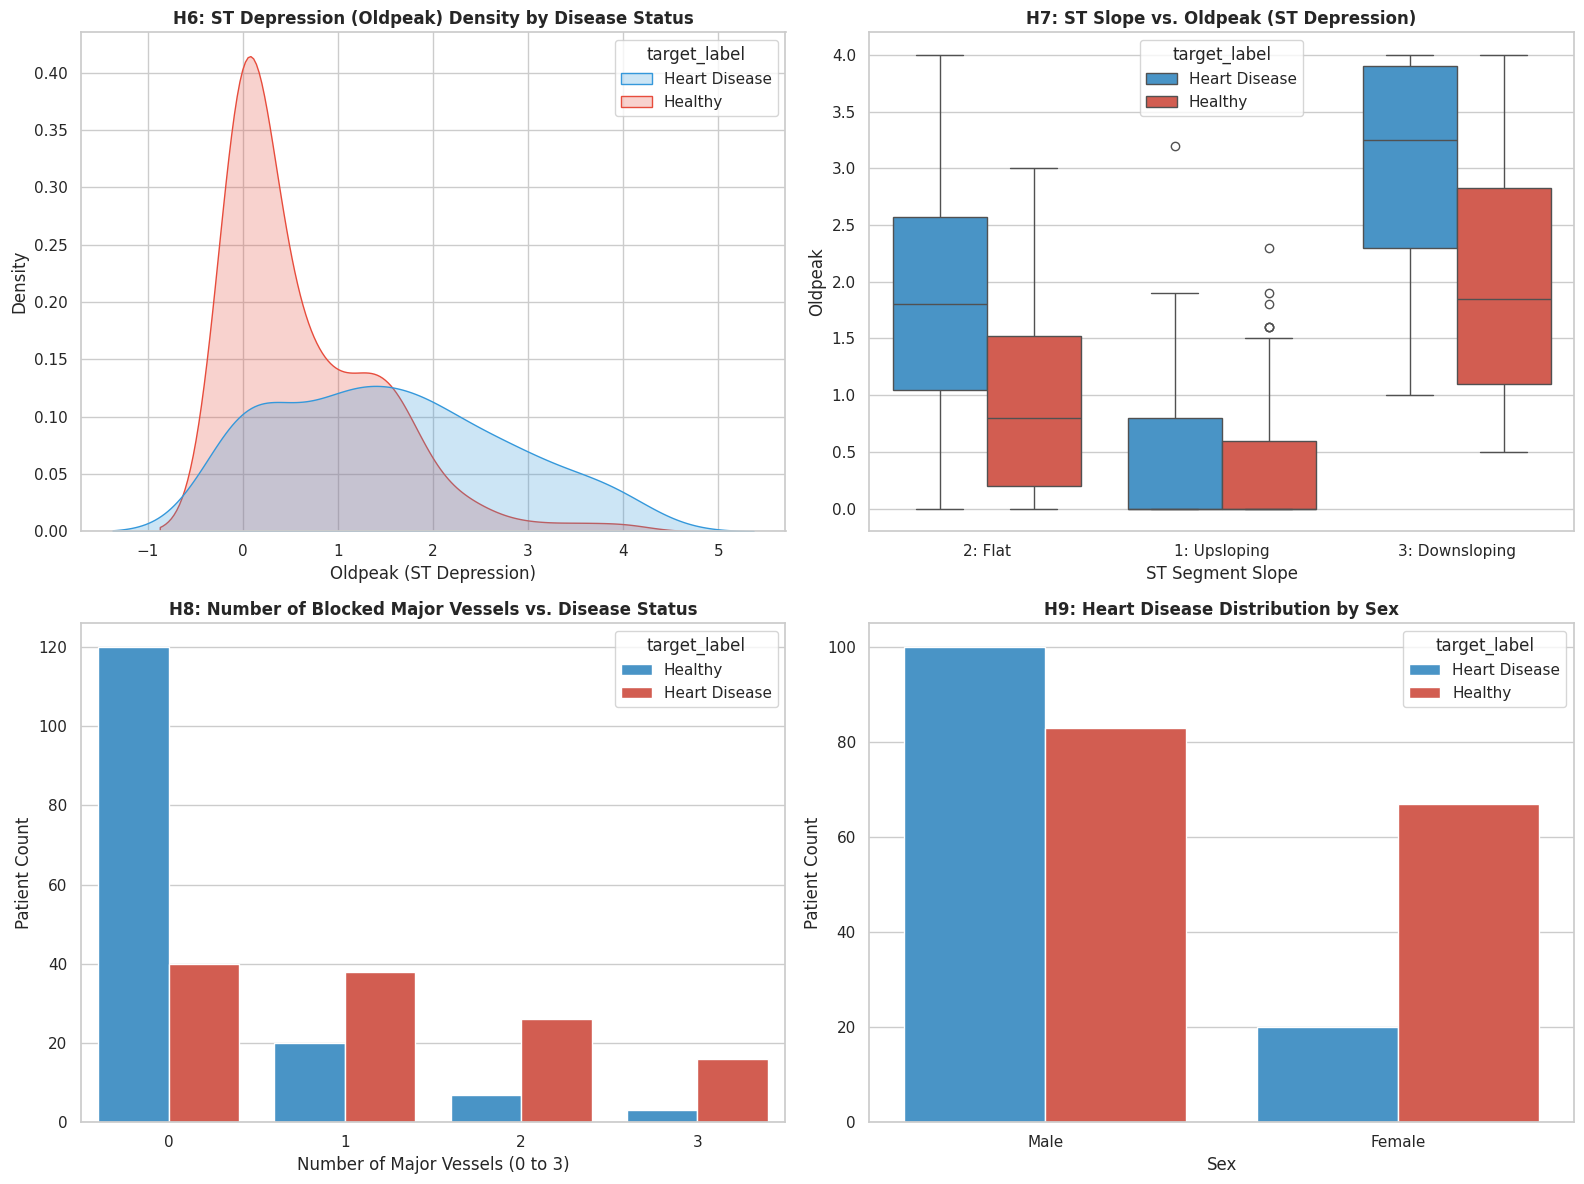

In [ ]:
# Ensure clean column names and mapped target
df.columns = df.columns.str.strip()
df_mapped = df.copy()
df_mapped['target_label'] = df_mapped['heart disease'].map({1: 'Healthy', 2: 'Heart Disease'})
df_mapped['sex_label'] = df_mapped['sex'].map({0: 'Female', 1: 'Male'})
df_mapped['slope_label'] = df_mapped['ST segment'].map({1: '1: Upsloping', 2: '2: Flat', 3: '3: Downsloping'})

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---------------------------------------------------------
# Plot 1 (H6): Oldpeak Distribution by Target (KDE Plot)
# ---------------------------------------------------------
sns.kdeplot(
    data=df_mapped,
    x='oldpeak',
    hue='target_label',
    shade=True,
    palette=['#3498db', '#e74c3c'],
    ax=axes[0, 0]
)
axes[0, 0].set_title('H6: ST Depression (Oldpeak) Density by Disease Status', fontweight='bold')
axes[0, 0].set_xlabel('Oldpeak (ST Depression)')

# ---------------------------------------------------------
# Plot 2 (H7): ST Segment Slope vs. Oldpeak (Boxplot)
# ---------------------------------------------------------
sns.boxplot(
    data=df_mapped,
    x='slope_label',
    y='oldpeak',
    hue='target_label',
    palette=['#3498db', '#e74c3c'],
    ax=axes[0, 1]
)
axes[0, 1].set_title('H7: ST Slope vs. Oldpeak (ST Depression)', fontweight='bold')
axes[0, 1].set_xlabel('ST Segment Slope')
axes[0, 1].set_ylabel('Oldpeak')

# ---------------------------------------------------------
# Plot 3 (H8): Major Vessels Colored by Fluoroscopy vs Target
# ---------------------------------------------------------
sns.countplot(
    data=df_mapped,
    x='major vessels',
    hue='target_label',
    palette=['#3498db', '#e74c3c'],
    ax=axes[1, 0]
)
axes[1, 0].set_title('H8: Number of Blocked Major Vessels vs. Disease Status', fontweight='bold')
axes[1, 0].set_xlabel('Number of Major Vessels (0 to 3)')
axes[1, 0].set_ylabel('Patient Count')

# ---------------------------------------------------------
# Plot 4 (H9): Sex vs Heart Disease Status
# ---------------------------------------------------------
sns.countplot(
    data=df_mapped,
    x='sex_label',
    hue='target_label',
    palette=['#3498db', '#e74c3c'],
    ax=axes[1, 1]
)
axes[1, 1].set_title('H9: Heart Disease Distribution by Sex', fontweight='bold')
axes[1, 1].set_xlabel('Sex')
axes[1, 1].set_ylabel('Patient Count')

plt.tight_layout()
plt.show()

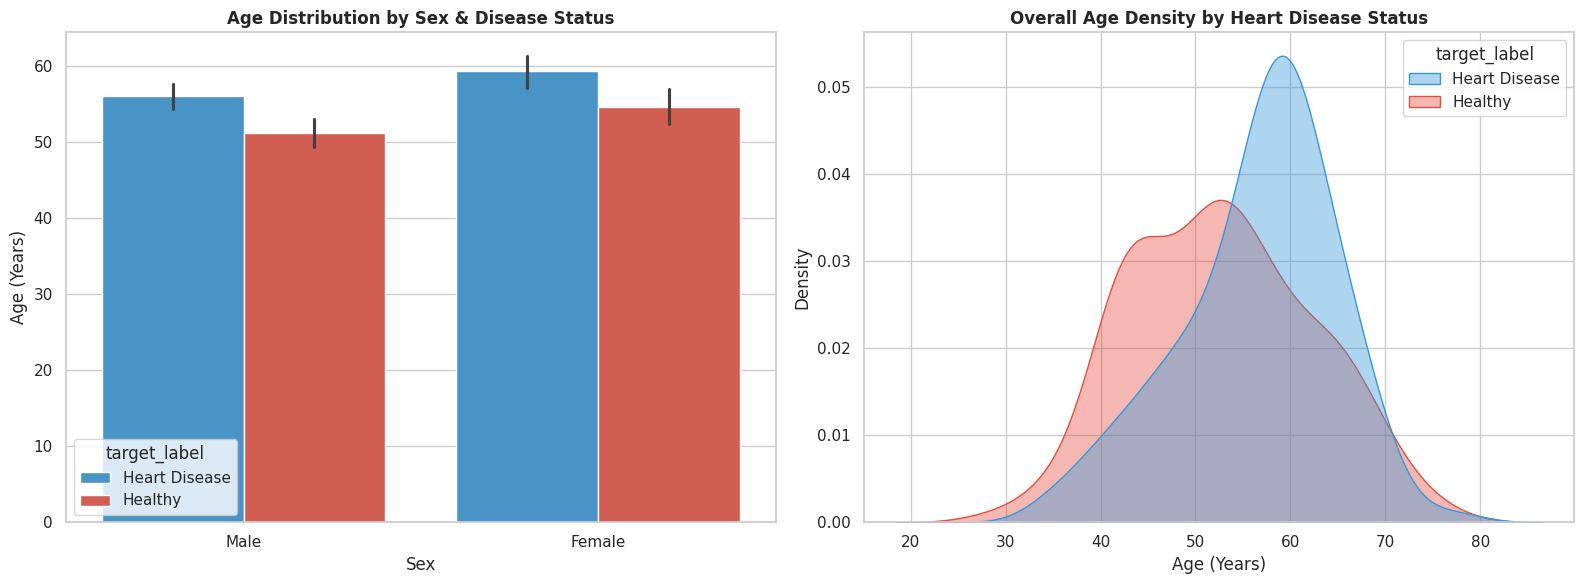

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean column names and map labels
df.columns = df.columns.str.strip()
df_mapped = df.copy()
df_mapped['target_label'] = df_mapped['heart disease'].map({1: 'Healthy', 2: 'Heart Disease'})
df_mapped['sex_label'] = df_mapped['sex'].map({0: 'Female', 1: 'Male'})

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Age vs. Sex vs. Target (Boxplot)
# ---------------------------------------------------------
sns.barplot(
    data=df_mapped,
    x='sex_label',
    y='age',
    hue='target_label',
    palette=['#3498db', '#e74c3c'],
    ax=axes[0]
)
axes[0].set_title('Age Distribution by Sex & Disease Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Age (Years)')

# ---------------------------------------------------------
# Plot 2: Age Density by Target (KDE Plot) - FIXED HERE
# ---------------------------------------------------------
sns.kdeplot(
    data=df_mapped,
    x='age',
    hue='target_label',
    fill=True,              # Updated from deprecated 'shade'
    common_norm=False,
    palette=['#3498db', '#e74c3c'],
    alpha=0.4,
    ax=axes[1]
)
axes[1].set_title('Overall Age Density by Heart Disease Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age (Years)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

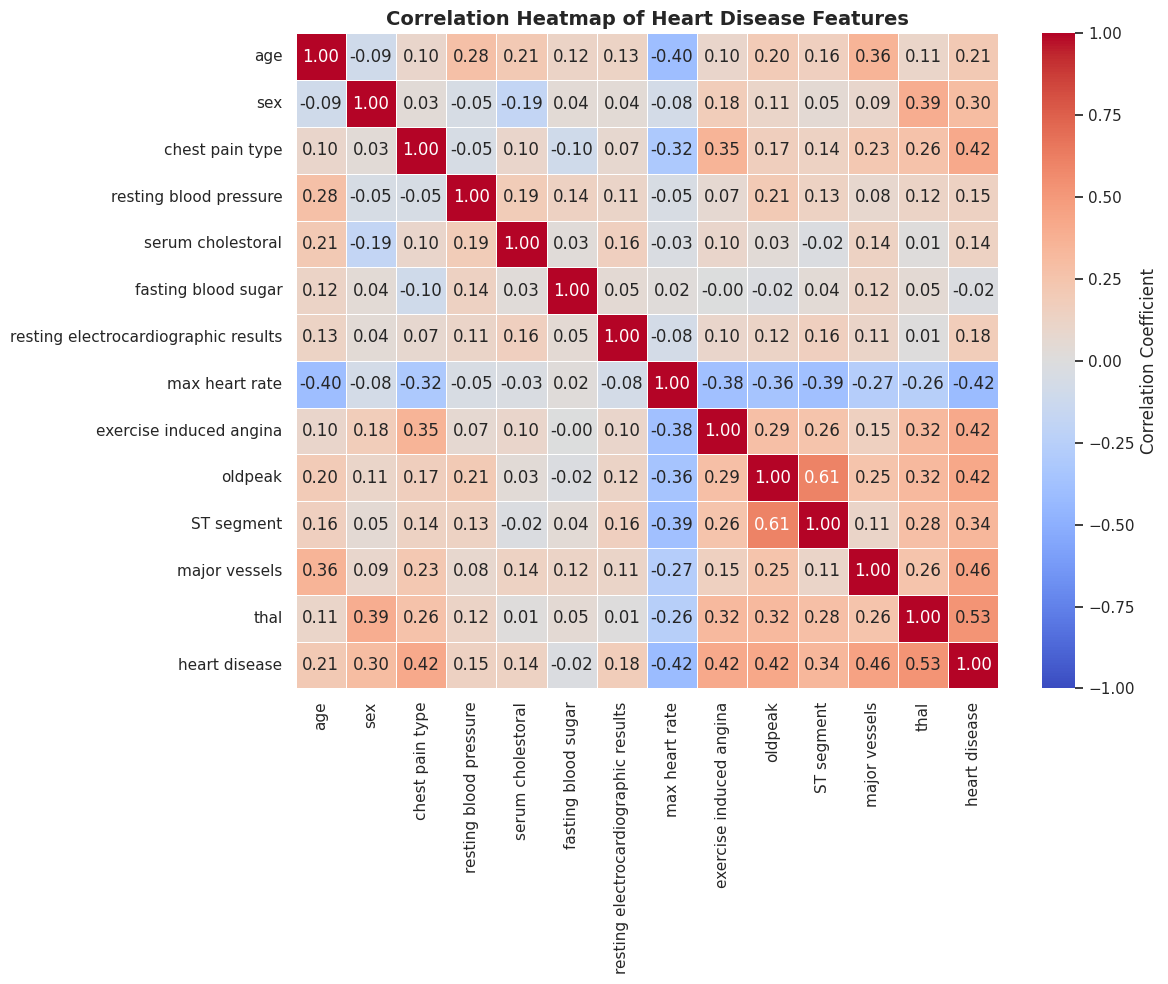

In [ ]:
# Compute the correlation matrix
plt.figure(figsize=(12, 10))
corr = df.corr()

# Create Heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Heatmap of Heart Disease Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

feature corelation ranking with target
- thal positive corelation
- major vessel +ve corr
- oldpeak  +ve corr
- chest pain type + corr
- max heart rate - ve corr
- exercise induce angina +ve corr
- st segemnt +ve corr
- sex +ve age
- age +ve corr
- fasting blood sugar ~0

Training Samples: 216 | Testing Samples: 54
       LOGISTIC REGRESSION PERFORMANCE       
Accuracy : 85.19%
Precision: 78.57%
Recall   : 91.67% (Crucial for medical diagnosis)
F1-Score : 84.62%
ROC-AUC  : 0.9014

Classification Report:
                precision    recall  f1-score   support

      Healthy       0.92      0.80      0.86        30
Heart Disease       0.79      0.92      0.85        24

     accuracy                           0.85        54
    macro avg       0.85      0.86      0.85        54
 weighted avg       0.86      0.85      0.85        54



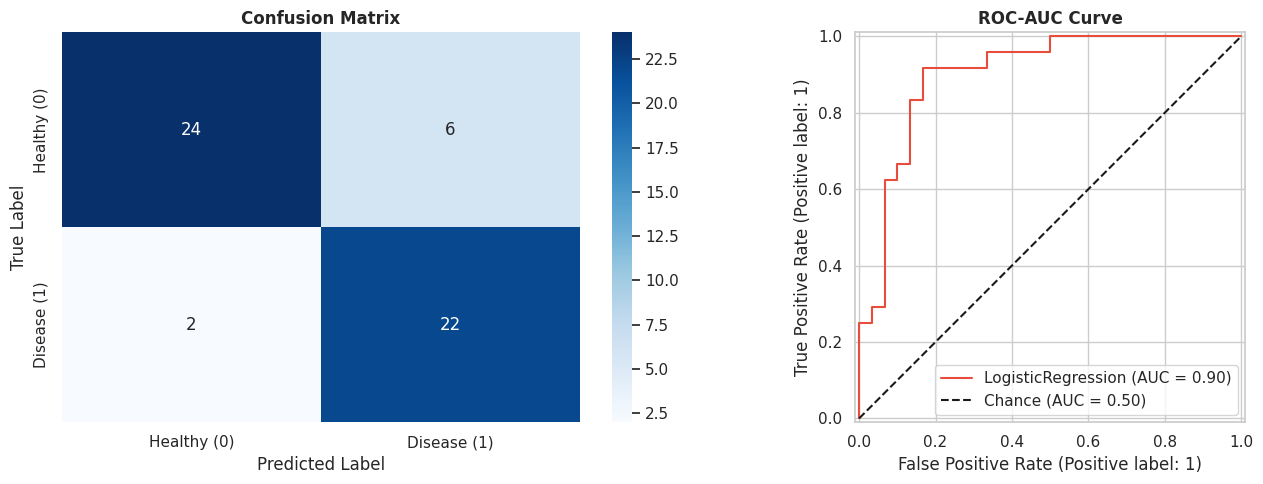

/tmp/ipykernel_1202/88708512.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


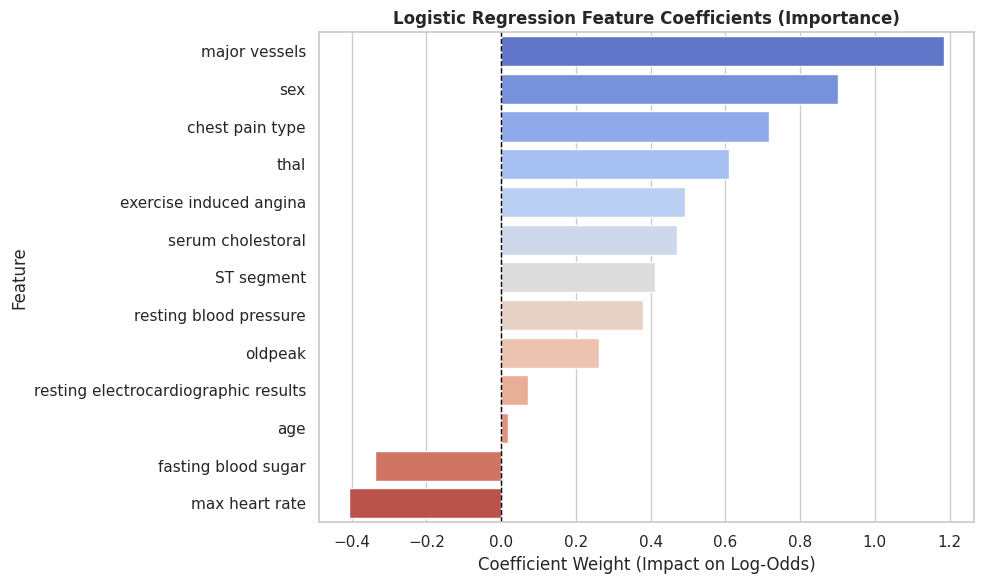

In [ ]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# ---------------------------------------------------------
# 1. Feature Matrix (X) & Target Vector (y)
# ---------------------------------------------------------
# Ensure target is binary: 0 = Healthy, 1 = Heart Disease
# If 'heart disease' is encoded as 1 and 2: map 1 -> 0, 2 -> 1
if df['heart disease'].max() == 2:
    y = df['heart disease'].map({1: 0, 2: 1})
else:
    y = df['heart disease']

X = df.drop(columns=['heart disease'])

# ---------------------------------------------------------
# 2. Train-Test Split (80% Train, 20% Test)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Samples: {X_train.shape[0]} | Testing Samples: {X_test.shape[0]}")

# ---------------------------------------------------------
# 3. Feature Scaling (StandardScaler)
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 4. Model Training (Logistic Regression)
# ---------------------------------------------------------
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# ---------------------------------------------------------
# 5. Performance Evaluation Metrics
# ---------------------------------------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 45)
print("       LOGISTIC REGRESSION PERFORMANCE       ")
print("=" * 45)
print(f"Accuracy : {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall   : {rec * 100:.2f}% (Crucial for medical diagnosis)")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("=" * 45)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Healthy', 'Heart Disease']))

# ---------------------------------------------------------
# 6. Confusion Matrix & ROC Curve Visualization
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Healthy (0)', 'Disease (1)'],
            yticklabels=['Healthy (0)', 'Disease (1)'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC Curve
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=axes[1], color='#e74c3c')
axes[1].set_title('ROC-AUC Curve', fontweight='bold')
axes[1].plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. Model Feature Coefficients (Weights Importance)
# ---------------------------------------------------------
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='Coefficient',
    y='Feature',
    palette='coolwarm'
)
plt.title('Logistic Regression Feature Coefficients (Importance)', fontweight='bold')
plt.xlabel('Coefficient Weight (Impact on Log-Odds)')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()